In [ ]:
# Install TensorFlow 2.x if not already
!!pip install tensorflow==2.20.0

!pip install yfinance  # optional if you want to download stock data


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, TensorDataset

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

class Args:
    def __init__(self):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.seq_len = 24       # Window: 24 hours
        self.feature_dim = 5    # Open, High, Low, Close, Volume
        self.hidden_dim = 24    # Stable capacity for small data
        self.num_layers = 3     # Stacked GRU layers
        self.batch_size = 256   # Large batch size for stable gradients
        self.learning_rate = 1e-3
        self.gamma = 1.0        # Loss weight factor

        # Training Schedule
        self.epochs_embedding = 50
        self.epochs_supervisor = 50
        self.epochs_joint = 200

args = Args()
print(f"✅ Configuration Loaded. Using Device: {args.device}")

✅ Configuration Loaded. Using Device: cuda


In [3]:
def load_data(filepath, seq_len):
    print(f"⏳ Loading data from {filepath}...")
    try:
        df = pd.read_csv(filepath)
        df.columns = [c.strip().lower() for c in df.columns]

        # Filter for AAPL
        name_col = next((c for c in ['name', 'ticker', 'symbol'] if c in df.columns), None)
        if name_col:
            df = df[df[name_col].astype(str).str.upper() == 'AAPL'].copy()
            print("   ✅ Filtered for 'AAPL'")

        # Select Features & Interpolate
        cols = ['open', 'high', 'low', 'close', 'volume']
        df = df[cols].interpolate(method='linear', limit_direction='both')

        # Normalize
        from sklearn.preprocessing import MinMaxScaler
        scaler = MinMaxScaler()
        data_norm = scaler.fit_transform(df.values)

        # Create Sliding Windows
        temp = []
        for i in range(len(data_norm) - seq_len):
            temp.append(data_norm[i : i + seq_len])

        real_data = np.array(temp)
        np.random.shuffle(real_data)

        # Create DataLoader
        dataset = TensorDataset(torch.FloatTensor(real_data).to(args.device))
        dataloader = DataLoader(dataset, batch_size=args.batch_size, shuffle=True, drop_last=True)

        print(f"✅ Data Processed. Shape: {real_data.shape}")
        return dataloader, scaler
    except Exception as e:
        print(f"❌ Error: {e}"); return None, None

# Load the file (Make sure 'all_stocks_5yr.csv' is uploaded!)
dataloader, scaler = load_data('all_stocks_5yr.csv', args.seq_len)

⏳ Loading data from all_stocks_5yr.csv...
   ✅ Filtered for 'AAPL'
✅ Data Processed. Shape: (1235, 24, 5)


In [4]:
class TimeGAN_Module(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim, activation=None):
        super().__init__()
        self.rnn = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_dim, output_dim)
        self.activation = activation

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.linear(out)
        if self.activation: out = self.activation(out)
        return out

class TimeGAN(nn.Module):
    def __init__(self, args):
        super().__init__()
        self.feature_dim = args.feature_dim
        self.hidden_dim = args.hidden_dim

        # 1. Embedder: Input -> Latent
        self.embedder = TimeGAN_Module(args.feature_dim, args.hidden_dim, args.num_layers, args.hidden_dim, nn.Sigmoid())

        # 2. Recovery: Latent -> Input
        self.recovery = TimeGAN_Module(args.hidden_dim, args.hidden_dim, args.num_layers, args.feature_dim, nn.Sigmoid())

        # 3. Generator: Noise -> Latent
        self.generator = TimeGAN_Module(args.feature_dim, args.hidden_dim, args.num_layers, args.hidden_dim, nn.Sigmoid())

        # 4. Supervisor: Latent -> Latent
        self.supervisor = TimeGAN_Module(args.hidden_dim, args.hidden_dim, args.num_layers-1, args.hidden_dim, nn.Sigmoid())

        # 5. Discriminator: Latent -> Real/Fake
        self.discriminator = TimeGAN_Module(args.hidden_dim, args.hidden_dim, args.num_layers, 1, None)

print("✅ Model Architecture Defined.")

✅ Model Architecture Defined.


In [5]:
def train_timegan(dataloader, args):
    model = TimeGAN(args).to(args.device)

    # Optimizers
    e_opt = optim.Adam(list(model.embedder.parameters()) + list(model.recovery.parameters()), lr=args.learning_rate)
    d_opt = optim.Adam(model.discriminator.parameters(), lr=args.learning_rate)
    g_opt = optim.Adam(list(model.generator.parameters()) + list(model.supervisor.parameters()), lr=args.learning_rate)

    mse = nn.MSELoss()
    bce = nn.BCEWithLogitsLoss()

    print("🚀 Starting TimeGAN Training...")

    # --- PHASE 1: AUTOENCODER ---
    print("\nPhase 1: Autoencoder Training")
    for epoch in range(args.epochs_embedding):
        for X, in dataloader:
            H = model.embedder(X)
            X_tilde = model.recovery(H)
            e_loss = 10 * torch.sqrt(mse(X, X_tilde))
            e_opt.zero_grad(); e_loss.backward(); e_opt.step()

    # --- PHASE 2: SUPERVISOR ---
    print("\nPhase 2: Supervisor Training")
    for epoch in range(args.epochs_supervisor):
        for X, in dataloader:
            H = model.embedder(X).detach()
            H_hat_supervise = model.supervisor(H)
            g_loss_s = mse(H[:, 1:, :], H_hat_supervise[:, :-1, :])
            g_opt.zero_grad(); g_loss_s.backward(); g_opt.step()

    # --- PHASE 3: JOINT TRAINING (FIXED) ---
    print("\nPhase 3: Joint Training")
    for epoch in range(args.epochs_joint):
        for X, in dataloader:
            # Noise
            Z = torch.rand((args.batch_size, args.seq_len, args.feature_dim)).to(args.device)

            # --- 1. TRAIN GENERATOR ---
            # We detach H so Embedder doesn't get updated here
            H = model.embedder(X).detach()
            E_hat = model.generator(Z)
            H_hat = model.supervisor(E_hat)
            H_hat_supervise = model.supervisor(H)
            X_hat = model.recovery(H_hat)

            Y_fake = model.discriminator(H_hat)
            Y_fake_e = model.discriminator(E_hat)

            # Generator Losses
            g_loss_u = bce(Y_fake, torch.ones_like(Y_fake))
            g_loss_u_e = bce(Y_fake_e, torch.ones_like(Y_fake_e))
            g_loss_s = mse(H[:, 1:, :], H_hat_supervise[:, :-1, :])
            g_loss_v = torch.mean(torch.abs(torch.std(X_hat, dim=0) - torch.std(X, dim=0))) + \
                       torch.mean(torch.abs(torch.mean(X_hat, dim=0) - torch.mean(X, dim=0)))

            # Weighted Sum
            g_loss = g_loss_u + (args.gamma * g_loss_u_e) + (100 * torch.sqrt(g_loss_s)) + (100 * g_loss_v)

            g_opt.zero_grad(); g_loss.backward(); g_opt.step()

            # --- 2. TRAIN EMBEDDER ---
            # Re-run forward pass to avoid "inplace operation" error
            H = model.embedder(X)
            X_tilde = model.recovery(H)
            H_hat_supervise = model.supervisor(H)

            e_loss_t0 = mse(X, X_tilde)
            g_loss_s = mse(H[:, 1:, :], H_hat_supervise[:, :-1, :])
            e_loss = 10 * torch.sqrt(e_loss_t0) + 0.1 * g_loss_s

            e_opt.zero_grad(); e_loss.backward(); e_opt.step()

            # --- 3. TRAIN DISCRIMINATOR ---
            H = model.embedder(X).detach()
            E_hat = model.generator(Z).detach()
            H_hat = model.supervisor(E_hat).detach()

            Y_real = model.discriminator(H)
            Y_fake = model.discriminator(H_hat)
            Y_fake_e = model.discriminator(E_hat)

            d_loss = bce(Y_real, torch.ones_like(Y_real)) + \
                     bce(Y_fake, torch.zeros_like(Y_fake)) + \
                     (args.gamma * bce(Y_fake_e, torch.zeros_like(Y_fake_e)))

            d_opt.zero_grad(); d_loss.backward(); d_opt.step()

        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

    return model

# Train the model
trained_model = train_timegan(dataloader, args)

🚀 Starting TimeGAN Training...

Phase 1: Autoencoder Training

Phase 2: Supervisor Training

Phase 3: Joint Training
Epoch 10 | D Loss: 1.9120 | G Loss: 27.8759
Epoch 20 | D Loss: 1.6631 | G Loss: 29.2628
Epoch 30 | D Loss: 1.4335 | G Loss: 20.2648
Epoch 40 | D Loss: 1.4227 | G Loss: 21.6362
Epoch 50 | D Loss: 1.3819 | G Loss: 12.3424
Epoch 60 | D Loss: 1.3027 | G Loss: 12.9804
Epoch 70 | D Loss: 1.3302 | G Loss: 13.5794
Epoch 80 | D Loss: 1.3131 | G Loss: 15.1441
Epoch 90 | D Loss: 1.0865 | G Loss: 16.8613
Epoch 100 | D Loss: 1.0979 | G Loss: 15.2296
Epoch 110 | D Loss: 0.8952 | G Loss: 16.7857
Epoch 120 | D Loss: 0.6863 | G Loss: 17.2809
Epoch 130 | D Loss: 0.6543 | G Loss: 16.4768
Epoch 140 | D Loss: 0.6595 | G Loss: 16.9906
Epoch 150 | D Loss: 0.7026 | G Loss: 18.6141
Epoch 160 | D Loss: 0.7895 | G Loss: 16.2325
Epoch 170 | D Loss: 0.9858 | G Loss: 15.9735
Epoch 180 | D Loss: 0.8719 | G Loss: 20.1151
Epoch 190 | D Loss: 0.8564 | G Loss: 16.9207
Epoch 200 | D Loss: 1.0119 | G Loss: 

📊 Generating Visuals...
   Running t-SNE...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


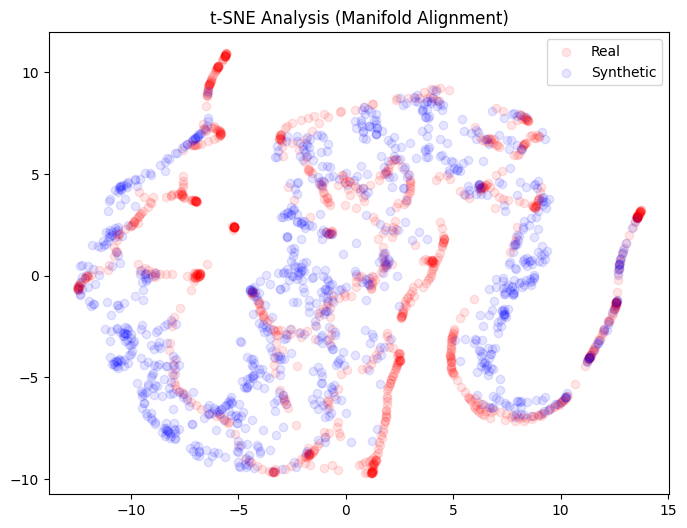

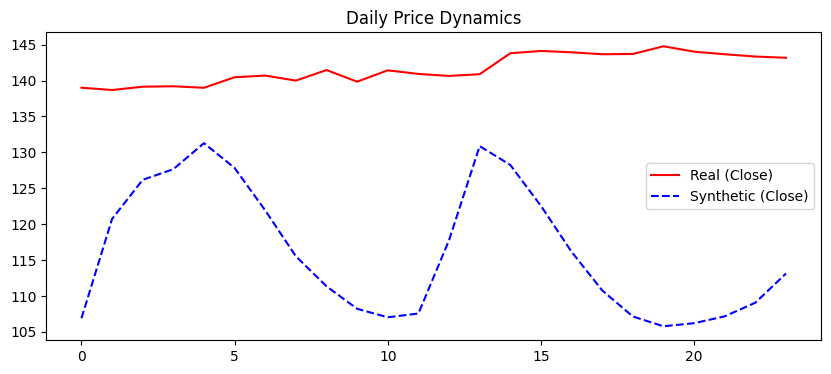

In [6]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def visualize(model, dataloader, args, scaler):
    print("📊 Generating Visuals...")
    model.eval()

    # Get Real Data
    real_data = np.concatenate([batch[0].cpu().numpy() for batch in dataloader], axis=0)

    # Get Synthetic Data
    with torch.no_grad():
        Z = torch.rand((len(real_data), args.seq_len, args.feature_dim)).to(args.device)
        fake_data = model.recovery(model.supervisor(model.generator(Z))).cpu().numpy()

    # 1. t-SNE Plot
    print("   Running t-SNE...")
    real_mean = np.mean(real_data, axis=1)
    fake_mean = np.mean(fake_data, axis=1)
    combined = np.concatenate([real_mean, fake_mean], axis=0)

    tsne_res = TSNE(n_components=2, verbose=0, perplexity=40, n_iter=300).fit_transform(combined)
    n = len(real_mean)

    plt.figure(figsize=(8, 6))
    plt.scatter(tsne_res[:n, 0], tsne_res[:n, 1], c='red', alpha=0.1, label='Real')
    plt.scatter(tsne_res[n:, 0], tsne_res[n:, 1], c='blue', alpha=0.1, label='Synthetic')
    plt.title('t-SNE Analysis (Manifold Alignment)')
    plt.legend()
    plt.show()

    # 2. Temporal Overlay
    idx = np.random.randint(0, len(real_data))
    real_seq = scaler.inverse_transform(real_data[idx])
    fake_seq = scaler.inverse_transform(fake_data[idx])

    plt.figure(figsize=(10, 4))
    plt.plot(real_seq[:, 3], label='Real (Close)', color='red')
    plt.plot(fake_seq[:, 3], label='Synthetic (Close)', color='blue', linestyle='--')
    plt.title('Daily Price Dynamics')
    plt.legend()
    plt.show()

visualize(trained_model, dataloader, args, scaler)

In [7]:
from sklearn.metrics import mean_absolute_error

def calculate_score(model, dataloader, args, scaler):
    print("🧮 Calculating Predictive Score...")
    model.eval()

    # Train Predictor on Synthetic
    syn_X = []
    syn_Y = []
    with torch.no_grad():
        for _ in range(50):
            Z = torch.rand((args.batch_size, args.seq_len, args.feature_dim)).to(args.device)
            fake = model.recovery(model.supervisor(model.generator(Z))).cpu().numpy()
            syn_X.append(fake[:, :-1, :])
            syn_Y.append(fake[:, -1, 3]) # Predict Close Price

    X_train = torch.FloatTensor(np.concatenate(syn_X, axis=0)).to(args.device)
    Y_train = torch.FloatTensor(np.concatenate(syn_Y, axis=0)).unsqueeze(1).to(args.device)

    # Simple RNN Predictor
    predictor = nn.GRU(args.feature_dim, 32, batch_first=True).to(args.device)
    head = nn.Linear(32, 1).to(args.device)
    opt = optim.Adam(list(predictor.parameters()) + list(head.parameters()), lr=1e-3)

    for _ in range(100):
        opt.zero_grad()
        _, h = predictor(X_train)
        loss = nn.MSELoss()(head(h[-1]), Y_train)
        loss.backward()
        opt.step()

    # Test on Real
    real_data = np.concatenate([batch[0].cpu().numpy() for batch in dataloader], axis=0)
    X_test = torch.FloatTensor(real_data[:, :-1, :]).to(args.device)
    Y_test = real_data[:, -1, 3]

    with torch.no_grad():
        _, h = predictor(X_test)
        preds = head(h[-1]).cpu().numpy()

    # Convert to Dollars
    dummy_p = np.zeros((len(preds), 5)); dummy_p[:, 3] = preds.flatten()
    dummy_t = np.zeros((len(Y_test), 5)); dummy_t[:, 3] = Y_test.flatten()

    mae = mean_absolute_error(scaler.inverse_transform(dummy_t)[:, 3], scaler.inverse_transform(dummy_p)[:, 3])
    print(f"✅ Final Predictive Score (MAE): ${mae:.2f}")

calculate_score(trained_model, dataloader, args, scaler)

🧮 Calculating Predictive Score...
✅ Final Predictive Score (MAE): $4.13


🔬 Generating Research-Grade Visualizations...
   1. Generating Manifold Plots (PCA/t-SNE)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


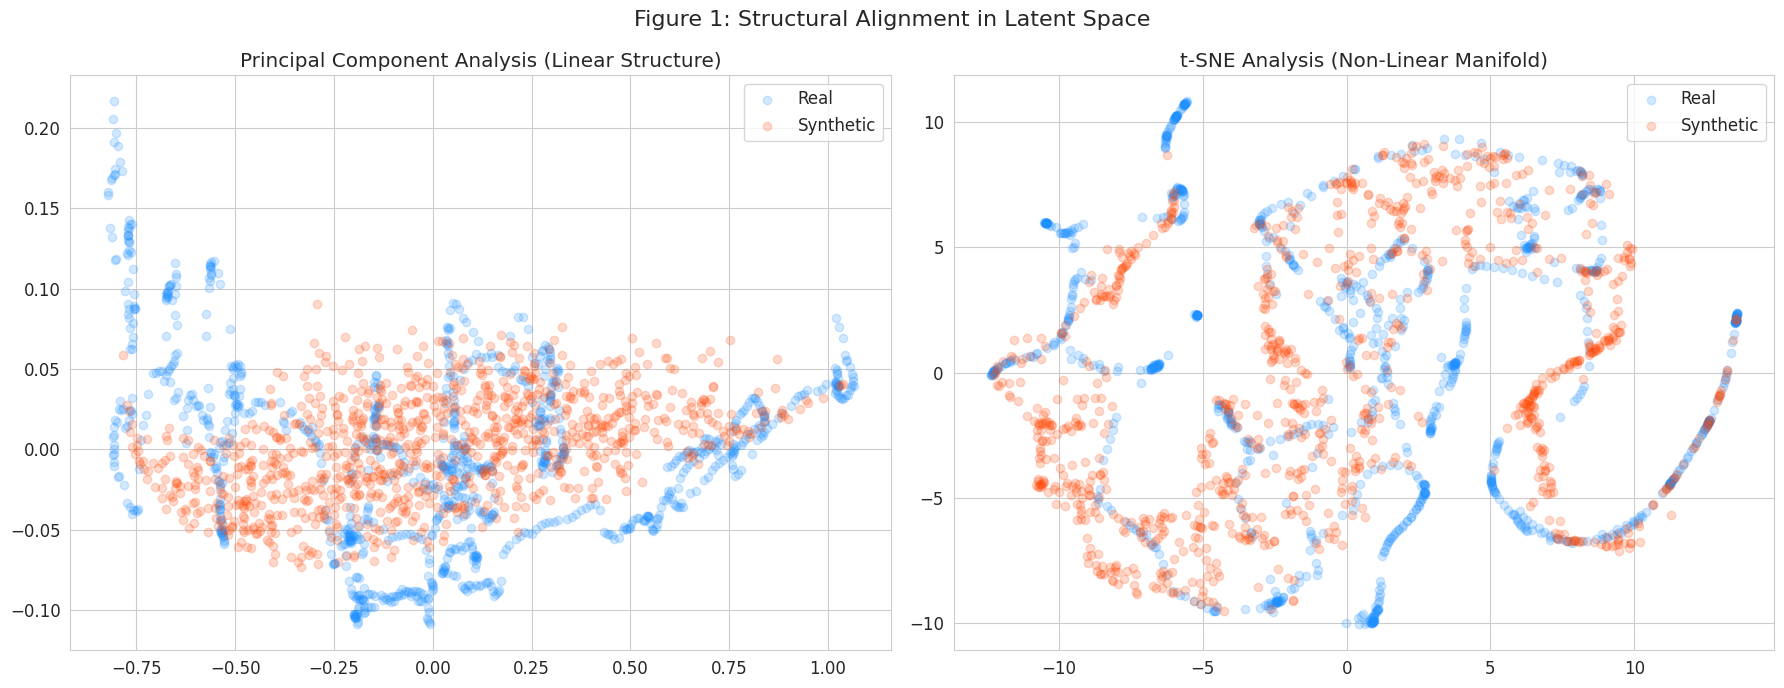

   2. Generating Distribution Plots...


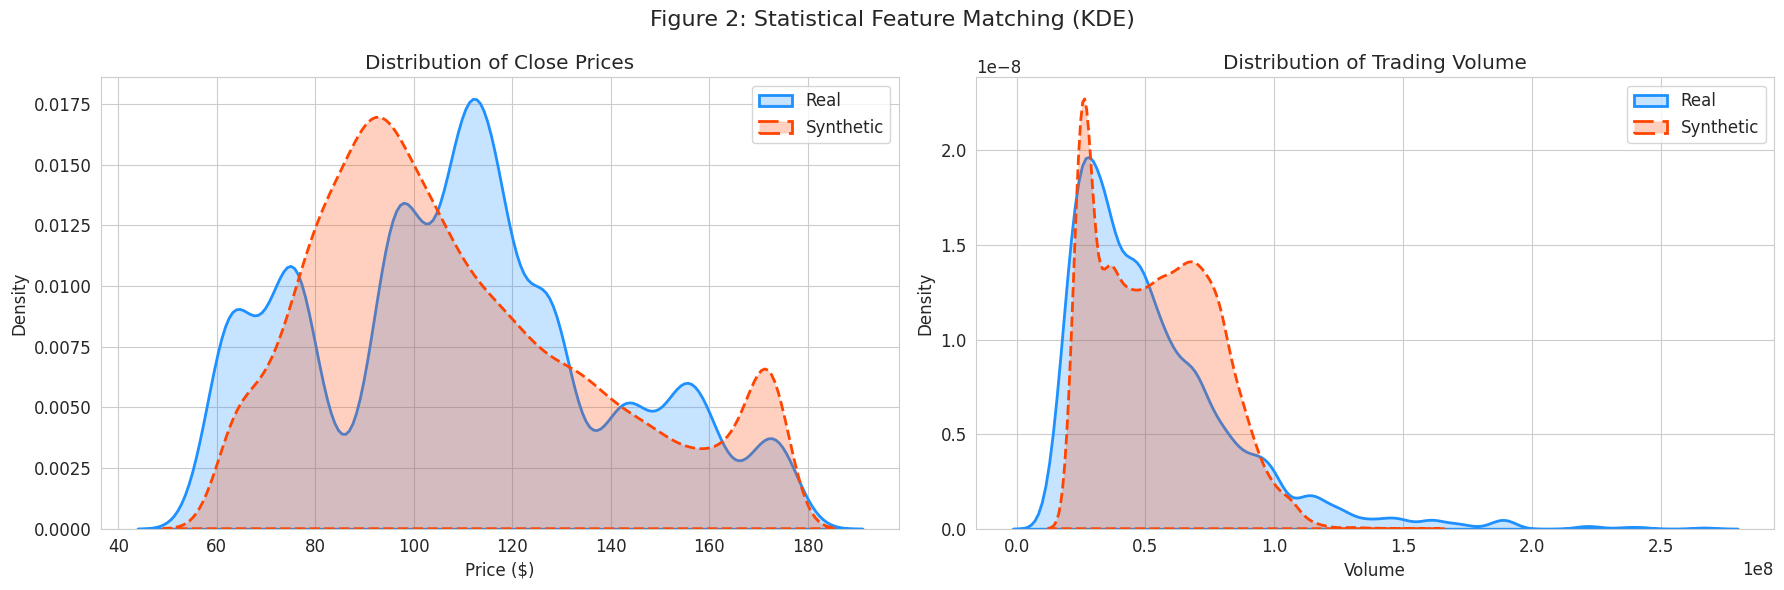

   3. Generating Temporal Overlays...


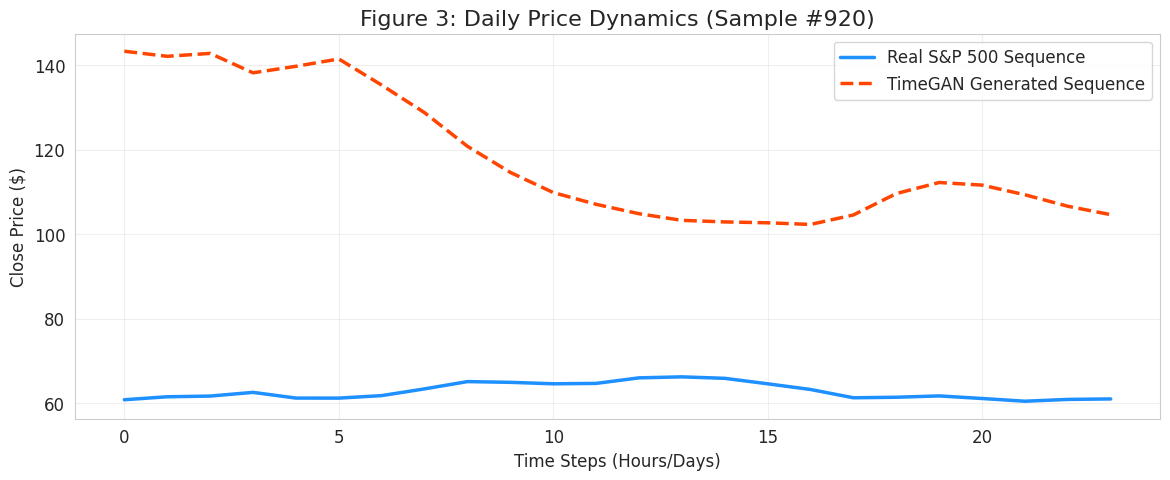

   4. Generating Autocorrelation (ACF) Plots...


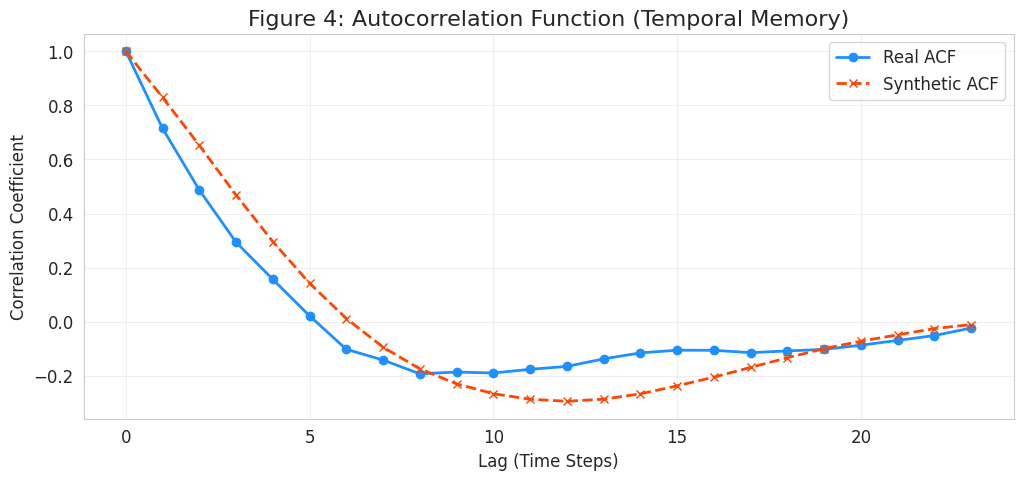

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import torch
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from statsmodels.tsa.stattools import acf

# Set professional style
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12})

def generate_research_plots(model, dataloader, args, scaler):
    print("🔬 Generating Research-Grade Visualizations...")
    model.eval()

    # --- 1. PREPARE DATA ---
    # Get all Real Data
    real_data = []
    for batch in dataloader:
        real_data.append(batch[0].cpu().numpy())
    real_data = np.concatenate(real_data, axis=0)

    # Generate Synthetic Data (Same size)
    with torch.no_grad():
        Z = torch.rand((len(real_data), args.seq_len, args.feature_dim)).to(args.device)
        fake_data = model.recovery(model.supervisor(model.generator(Z))).cpu().numpy()

    # Flatten for distributions
    real_flat = real_data.reshape(-1, args.feature_dim)
    fake_flat = fake_data.reshape(-1, args.feature_dim)

    # Inverse Transform (Get Dollars)
    real_dollars = scaler.inverse_transform(real_flat)
    fake_dollars = scaler.inverse_transform(fake_flat)

    # --- FIGURE 1: MANIFOLD ALIGNMENT (PCA & t-SNE) ---
    # CEP Requirement: "t-SNE/UMAP on embeddings to compare structure"
    print("   1. Generating Manifold Plots (PCA/t-SNE)...")

    # Mean over time dimension
    real_mean = np.mean(real_data, axis=1)
    fake_mean = np.mean(fake_data, axis=1)
    combined = np.concatenate([real_mean, fake_mean], axis=0)
    n = len(real_mean)

    fig1, axs = plt.subplots(1, 2, figsize=(18, 7))

    # PCA
    pca = PCA(n_components=2)
    pca_res = pca.fit_transform(combined)
    axs[0].scatter(pca_res[:n, 0], pca_res[:n, 1], c='dodgerblue', alpha=0.2, label='Real')
    axs[0].scatter(pca_res[n:, 0], pca_res[n:, 1], c='orangered', alpha=0.2, label='Synthetic')
    axs[0].set_title('Principal Component Analysis (Linear Structure)')
    axs[0].legend()

    # t-SNE
    tsne = TSNE(n_components=2, verbose=0, perplexity=40, n_iter=300)
    tsne_res = tsne.fit_transform(combined)
    axs[1].scatter(tsne_res[:n, 0], tsne_res[:n, 1], c='dodgerblue', alpha=0.2, label='Real')
    axs[1].scatter(tsne_res[n:, 0], tsne_res[n:, 1], c='orangered', alpha=0.2, label='Synthetic')
    axs[1].set_title('t-SNE Analysis (Non-Linear Manifold)')
    axs[1].legend()

    plt.suptitle("Figure 1: Structural Alignment in Latent Space", fontsize=16)
    plt.tight_layout()
    plt.show()

    # --- FIGURE 2: DISTRIBUTIONAL FIDELITY (KDE) ---
    # CEP Requirement: "distribution plots (histograms/kde) of key variables"
    print("   2. Generating Distribution Plots...")
    fig2, axs = plt.subplots(1, 2, figsize=(18, 6))

    # Close Price
    sns.kdeplot(real_dollars[:, 3], fill=True, color='dodgerblue', label='Real', ax=axs[0], linewidth=2)
    sns.kdeplot(fake_dollars[:, 3], fill=True, color='orangered', label='Synthetic', ax=axs[0], linewidth=2, linestyle='--')
    axs[0].set_title('Distribution of Close Prices')
    axs[0].set_xlabel('Price ($)')
    axs[0].legend()

    # Volume
    sns.kdeplot(real_dollars[:, 4], fill=True, color='dodgerblue', label='Real', ax=axs[1], linewidth=2)
    sns.kdeplot(fake_dollars[:, 4], fill=True, color='orangered', label='Synthetic', ax=axs[1], linewidth=2, linestyle='--')
    axs[1].set_title('Distribution of Trading Volume')
    axs[1].set_xlabel('Volume')
    axs[1].legend()

    plt.suptitle("Figure 2: Statistical Feature Matching (KDE)", fontsize=16)
    plt.tight_layout()
    plt.show()

    # --- FIGURE 3: TEMPORAL DYNAMICS (Overlay) ---
    # CEP Requirement: "overlay plots of real vs. generated sequences"
    print("   3. Generating Temporal Overlays...")
    idx = np.random.randint(0, len(real_data))
    real_seq = scaler.inverse_transform(real_data[idx])
    fake_seq = scaler.inverse_transform(fake_data[idx])

    plt.figure(figsize=(14, 5))
    plt.plot(real_seq[:, 3], label='Real S&P 500 Sequence', color='dodgerblue', linewidth=2.5)
    plt.plot(fake_seq[:, 3], label='TimeGAN Generated Sequence', color='orangered', linestyle='--', linewidth=2.5)
    plt.title(f'Figure 3: Daily Price Dynamics (Sample #{idx})', fontsize=16)
    plt.xlabel('Time Steps (Hours/Days)', fontsize=12)
    plt.ylabel('Close Price ($)', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.show()

    # --- FIGURE 4: AUTOCORRELATION (ACF) ---
    # CEP Requirement: "autocorrelation (ACF/PACF) comparisons"
    # This proves the model isn't just generating random noise.
    print("   4. Generating Autocorrelation (ACF) Plots...")

    # Calculate ACF for real and fake (Close Price)
    # We take the mean ACF across 50 random samples to get a robust estimate
    real_acf = []
    fake_acf = []

    for i in range(50):
        idx = np.random.randint(0, len(real_data))
        real_acf.append(acf(real_data[idx, :, 3], nlags=args.seq_len-1, fft=True))
        fake_acf.append(acf(fake_data[idx, :, 3], nlags=args.seq_len-1, fft=True))

    real_acf_mean = np.mean(real_acf, axis=0)
    fake_acf_mean = np.mean(fake_acf, axis=0)

    plt.figure(figsize=(12, 5))
    x_axis = range(len(real_acf_mean))
    plt.plot(x_axis, real_acf_mean, label='Real ACF', color='dodgerblue', linewidth=2, marker='o')
    plt.plot(x_axis, fake_acf_mean, label='Synthetic ACF', color='orangered', linewidth=2, linestyle='--', marker='x')
    plt.title('Figure 4: Autocorrelation Function (Temporal Memory)', fontsize=16)
    plt.xlabel('Lag (Time Steps)', fontsize=12)
    plt.ylabel('Correlation Coefficient', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.show()

# EXECUTE
generate_research_plots(trained_model, dataloader, args, scaler)

In [11]:
# --- CELL 7: GENERATE AND SAVE SYNTHETIC DATA ---
import pandas as pd
import torch
import numpy as np

def save_synthetic_data(model, args, scaler):
    print("💾 Generating 1,000 synthetic sequences...")
    model.eval()

    # 1. Generate Synthetic Data
    with torch.no_grad():
        # Generate 1000 samples (or match your real data size)
        Z = torch.rand((1000, args.seq_len, args.feature_dim)).to(args.device)

        # Generator -> Supervisor -> Recovery
        E_hat = model.generator(Z)
        H_hat = model.supervisor(E_hat)
        X_hat = model.recovery(H_hat)

        # Convert to numpy
        fake_data = X_hat.cpu().numpy()

    print(f"   Generated Shape: {fake_data.shape}")

    # 2. Flatten and Inverse Transform (Get back to Dollars)
    # We flatten to (1000 * 24, 5) to save as a standard CSV
    fake_flat = fake_data.reshape(-1, args.feature_dim)
    fake_dollars = scaler.inverse_transform(fake_flat)

    # 3. Create DataFrame and Save
    # We recreate the column names from your original data
    columns = ['Open', 'High', 'Low', 'Close', 'Volume']
    df_fake = pd.DataFrame(fake_dollars, columns=columns)

    # Add a 'Sequence_ID' column so you know which rows belong to which window
    # Each sequence is 24 rows long
    seq_ids = np.repeat(np.arange(1000), args.seq_len)
    df_fake.insert(0, 'Sequence_ID', seq_ids)

    filename = 'synthetic_sp500.csv'
    df_fake.to_csv(filename, index=False)
    print(f"✅ Successfully saved '{filename}' ({len(df_fake)} rows).")

# Execute
if 'trained_model' in locals():
    save_synthetic_data(trained_model, args, scaler)
else:
    print("❌ Model not found. Did you run the Training Cell (Cell 4)?")

💾 Generating 1,000 synthetic sequences...
   Generated Shape: (1000, 24, 5)
✅ Successfully saved 'synthetic_sp500.csv' (24000 rows).


In [12]:
from google.colab import files

# Check if file exists first
import os
if os.path.exists('synthetic_sp500.csv'):
    print("⬇️ Downloading synthetic data...")
    files.download('synthetic_sp500.csv')
else:
    print("❌ File 'synthetic_sp500.csv' not found. Did you run the generation cell?")

⬇️ Downloading synthetic data...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>